# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.DataFrame({"Expressao": np.random.normal(0,3,1000)})
df.head()

,Expressao
0,-4.684573
1,-6.127620
2,-1.139845
3,3.969200
4,-5.482835


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [5]:
# Variáveis auxiliares
genes_up = np.random.randint(100, 500, 1000)
genes_down = np.random.randint(0, 500, 1000)
genes = [f'Gene_{i+1}' for i in range(1000)]

# Classificação correta
regulacao = ['Up' if x > 0 else 'Down' for x in df['Expressao']]

# Criar DataFrame final
df_genes = pd.DataFrame({
    'Gene': genes,
    'Expressao': df['Expressao'],
    'Regulacao': regulacao
})

# Pacientes
df_genes['Paciente'] = [f'Paciente_{i+1}' for i in range(1000)]
df_genes['n_up'] = genes_up
df_genes['n_down'] = genes_down

df_genes.head()

,Gene,Expressao,Regulacao,Paciente,n_up,n_down
0,Gene_1,-4.684573,Down,Paciente_1,207,357
1,Gene_2,-6.127620,Down,Paciente_2,266,136
2,Gene_3,-1.139845,Down,Paciente_3,416,398
3,Gene_4,3.969200,Up,Paciente_4,102,461
4,Gene_5,-5.482835,Down,Paciente_5,290,99


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados de expressão gênica foram categorizados em 6 grupos por meio de discretização (binning), utilizando intervalos definidos entre -3 e 3. Esses intervalos foram escolhidos com base na distribuição normal dos dados gerados, que possui média zero. Valores negativos representam genes downregulated, enquanto valores positivos representam genes upregulated. A divisão em faixas permite classificar os níveis de expressão em diferentes intensidades, desde fortemente downregulated até fortemente upregulated.

In [14]:
bins = [-np.inf, -2, -1, 0, 1, 2, np.inf]

df_genes['categoria'] = pd.cut(df_genes['Expressao'], 
                               bins=bins, 
                               labels=['A', 'B', 'C', 'D', 'E', 'F'])

df_genes.head()

,Gene,Expressao,Regulacao,Paciente,n_up,n_down,categoria
0,Gene_1,-4.684573,Down,Paciente_1,207,357,A
1,Gene_2,-6.127620,Down,Paciente_2,266,136,A
2,Gene_3,-1.139845,Down,Paciente_3,416,398,B
3,Gene_4,3.969200,Up,Paciente_4,102,461,F
4,Gene_5,-5.482835,Down,Paciente_5,290,99,A


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [15]:
def tabela_frequencia(serie: pd.Series) -> pd.DataFrame:
    '''
        Recebe um pd.Series, que no caso pode ser a coluna de Expressão do df original.
        Retorna outra df, contendo a frequência relativa.
    '''
    freq_abs = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()
    
    df_freq = pd.DataFrame({
        'freq_abs': freq_abs,
        'freq_rel': freq_rel
    })
    
    return df_freq

In [16]:
# Variável do ex. 1
classes = pd.cut(df_genes['Expressao'], bins=6)

# Tabela de frequencia
frequencia_expressão = tabela_frequencia(classes)
frequencia_expressão.head()

,freq_abs,freq_rel
Expressao,,
"(-9.317, -6.328]",20,0.020
"(-6.328, -3.357]",113,0.113
"(-3.357, -0.386]",336,0.336
"(-0.386, 2.585]",339,0.339
"(2.585, 5.556]",161,0.161


In [18]:
# Variável do ex. 2
df_up = tabela_frequencia(df_genes['n_up'])
df_down = tabela_frequencia(df_genes['n_down'])

In [19]:
df_up.head()

,freq_abs,freq_rel
n_up,,
100,2,0.002
101,3,0.003
102,4,0.004
103,1,0.001
104,5,0.005


In [20]:
df_down.head()

,freq_abs,freq_rel
n_down,,
1,2,0.002
2,3,0.003
3,4,0.004
4,2,0.002
5,1,0.001


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

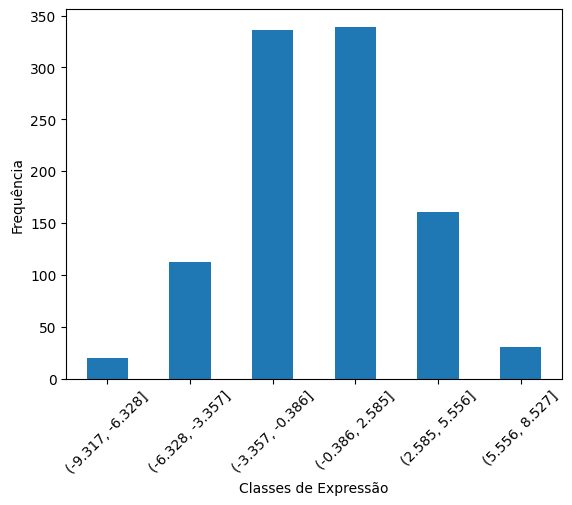

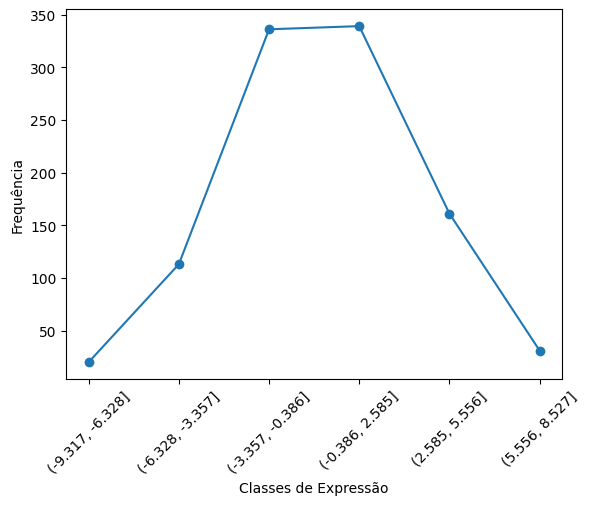

In [21]:
# gráfico de barras
frequencia_expressão['freq_abs'].plot(kind='bar')
plt.xlabel('Classes de Expressão')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

# gráfico de linhas
frequencia_expressão['freq_abs'].plot(kind='line', marker='o')
plt.xlabel('Classes de Expressão')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

### Número

In [11]:
#  Tabela de frequencia da outra variavel
frequencia_categoria = tabela_frequencia(df['categoria'])
frequencia_categoria.head()

,freq_rel
categoria,
A,0.143485
B,0.177160
C,0.183016
D,0.178624
E,0.162518


<Axes: xlabel='categoria'>

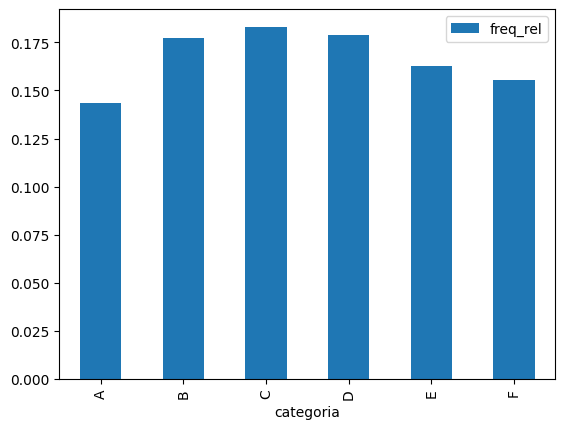

In [12]:
frequencia_categoria.plot.bar()

<Axes: xlabel='categoria'>

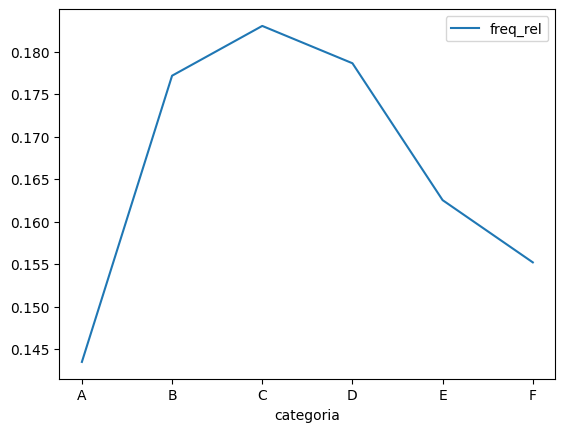

In [13]:
frequencia_categoria.plot.line()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

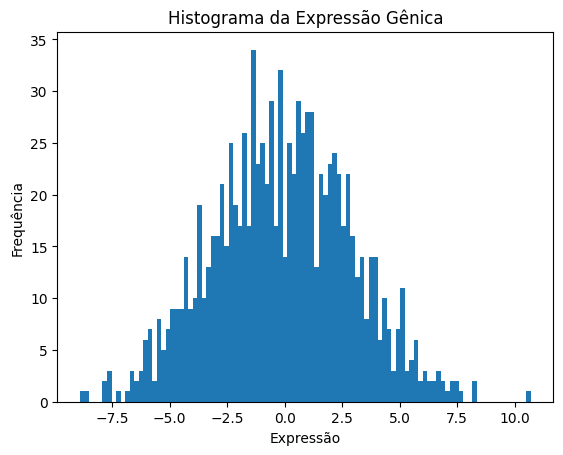

In [16]:
plt.hist(df['Expressao'], bins=100)
plt.title('Histograma da Expressão Gênica')
plt.xlabel('Expressão')
plt.ylabel('Frequência')

plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

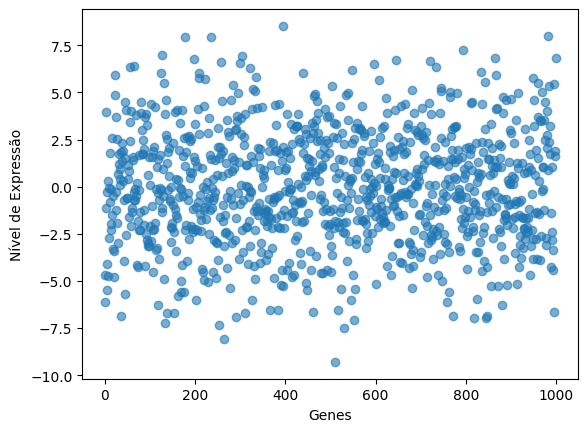

In [22]:
plt.scatter(df_genes.index, df_genes['Expressao'], alpha=0.6)

plt.xlabel('Genes')
plt.ylabel('Nível de Expressão')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

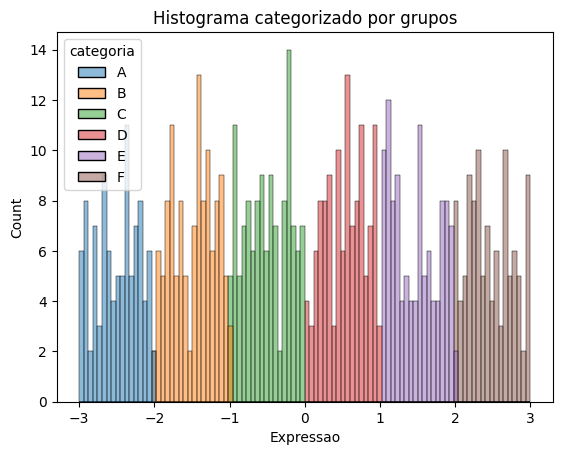

In [26]:
sns.histplot(data=df, x='Expressao', hue='categoria', bins=100)

plt.title('Histograma categorizado por grupos')
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

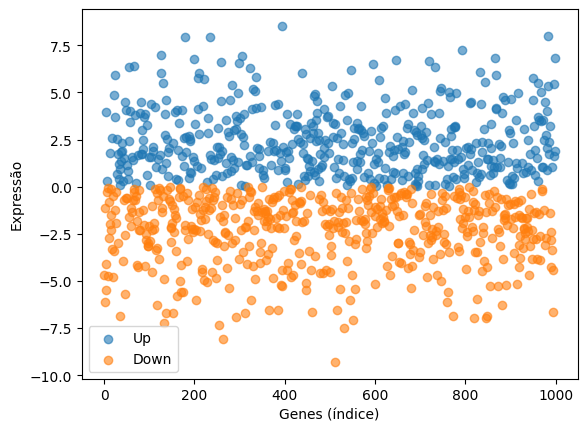

In [24]:
# categorizar
up = df_genes[df_genes['Regulacao'] == 'Up']
down = df_genes[df_genes['Regulacao'] == 'Down']

# gráfico
plt.scatter(up.index, up['Expressao'], label='Up', alpha=0.6)
plt.scatter(down.index, down['Expressao'], label='Down', alpha=0.6)

plt.xlabel('Genes (índice)')
plt.ylabel('Expressão')
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

| Variável                | Tipo         |
| ----------------------- | ------------ |
| # de células positivas  | **Discreta** |
| % de células positivas  | **Contínua** |
| Faixa de pH             | **Ordinal**  |
| Valor de pH             | **Contínua** |
| mol/L                   | **Contínua** |
| UFC                     | **Discreta** |
| D.O. (densidade óptica) | **Contínua** |
| Grupo Sanguíneo         | **Nominal**  |
| Sorologia               | **Nominal**  |
